# Gran Canaria Weekly Audit + EDA

**Project:** Climate–Mortality  
#### EDA scope for this notebook
#### Island: set via `gran_canaria`
#### Dataset version used here: 2016–2025

**Saved outputs:** QA tables and key descriptive tables (CSV) under `reports/islands/tables/gran_canaria`.

## 0. Setup

In [19]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ISLAND_NAME = "gran_canaria"
ISLAND_CODE = "gcan"

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary,
    autosave_fig, save_table,
)

REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2016_2025.parquet"
print("FP:", FP)
assert FP.exists(), f"Missing file: {FP}"

CWD : C:\Users\fdora\RA_Career\Projects\climate_mortality\islands\gran_canaria
ROOT: C:\Users\fdora\RA_Career\Projects\climate_mortality
src exists?: True
FIG_DIR: C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\gran_canaria
TAB_DIR: C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria
FP: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\gran_canaria\master\master_gcan_2016_2025.parquet


## 1. Load data
Load the island master dataset and subset.

In [20]:
section(f"EDA core weekly {ISLAND_NAME}")

df = pd.read_parquet(FP)
print("Loaded:", FP)

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
print("Week range:", df["week_start"].min(), "->", df["week_start"].max())
glance(df, label=f"eda_core_weekly_{ISLAND_CODE}", n=5)

checks(
    df,
    required=["week_start", "deaths_week"],
    key=["week_start"],
    dt="week_start"
)

num_summary(df)


EDA core weekly gran_canaria
Loaded: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\gran_canaria\master\master_gcan_2016_2025.parquet
Week range: 2015-12-28 00:00:00 -> 2025-12-29 00:00:00

--- eda_core_weekly_gcan ---
shape: (523, 42)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week                   float64
n_days                                  int64
temp_c_mean                           float64
tmax_c_mean                           float64
tmax_c_max                            float64
tmin_c_mean                           float64
tmin_c_min                            float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
prec_sum                              float

,week_start,year,island,island_code,deaths_week,deaths_missing_week,n_days,temp_c_mean,tmax_c_mean,tmax_c_max,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,gran_canaria,gcan,NaN,NaN,3,19.500000,22.333333,22.9,...,69.333333,3,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,gran_canaria,gcan,126.0,0.0,7,19.400000,22.557143,24.4,...,64.142857,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,gran_canaria,gcan,127.0,0.0,7,20.528571,23.871429,28.1,...,54.857143,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2016-01-18,2016,gran_canaria,gcan,135.0,0.0,7,20.071429,22.842857,24.0,...,65.000000,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2016-01-25,2016,gran_canaria,gcan,136.0,0.0,7,20.100000,22.771429,24.5,...,74.857143,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
year,523.0,2020.491396,2.883003,2015.000000,2018.000000,2020.000000,2023.000000,2025.000000
deaths_week,522.0,135.421456,20.721593,89.000000,120.000000,134.000000,148.000000,209.000000
deaths_missing_week,522.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
n_days,523.0,6.770554,0.768721,0.000000,7.000000,7.000000,7.000000,7.000000
temp_c_mean,523.0,21.801315,2.641806,15.642857,19.621429,21.728571,24.028571,28.828571
tmax_c_mean,523.0,24.885285,2.746063,18.528571,22.646429,24.828571,26.964286,33.228571
tmax_c_max,523.0,26.748948,3.432537,19.500000,24.000000,26.500000,28.750000,39.900000
tmin_c_mean,523.0,18.718579,2.605186,12.742857,16.445238,18.550000,21.121429,24.928571
tmin_c_min,523.0,17.540535,2.823092,9.700000,15.200000,17.300000,20.100000,24.000000
humidity_mean,523.0,63.840497,5.597691,36.571429,61.000000,64.285714,67.071429,78.714286


In [21]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df["month"] = df["week_start"].dt.month

if "tmax_anom_mean" not in df.columns and "tmax_c_mean" in df.columns:
    monthly_ref = df.groupby("month")["tmax_c_mean"].transform("mean")
    df["tmax_anom_mean"] = df["tmax_c_mean"] - monthly_ref
    print("Created tmax_anom_mean from tmax_c_mean using month-of-year mean.")
elif "tmax_anom_mean" in df.columns:
    print("tmax_anom_mean already present.")
else:
    print("Missing base column tmax_c_mean.")

if {"deaths_week", "tmax_anom_mean"}.issubset(df.columns):
    corr_tmax_anom = df[["deaths_week", "tmax_anom_mean"]].dropna().corr().iloc[0, 1]
    print("Corr Tmax_anom:", corr_tmax_anom)

Created tmax_anom_mean from tmax_c_mean using month-of-year mean.
Corr Tmax_anom: 0.07579181061600901


In [22]:
if "excess_deaths" not in df.columns and "deaths_week" in df.columns:
    deaths_ref = df.groupby("month")["deaths_week"].transform("mean")
    df["excess_deaths"] = df["deaths_week"] - deaths_ref
    print("Created excess_deaths from deaths_week using month-of-year mean.")
else:
    print("excess_deaths already present or deaths_week missing.")

Created excess_deaths from deaths_week using month-of-year mean.


In [23]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

if "island_code" in df.columns:
    df = df.loc[df["island_code"].eq(ISLAND_CODE)].copy()

df = df.sort_values("week_start").reset_index(drop=True)
glance(df, label=f"{ISLAND_CODE}_master_weekly", n=5)

calima_fp = ROOT / "data" / "processed" / ISLAND_NAME / "calima" / f"calima_proxy_weekly_{ISLAND_CODE}_2016_2025.parquet"
print("Calima proxy FP:", calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima["week_start"] = pd.to_datetime(calima["week_start"], errors="coerce")
    keep = [
    "week_start",
    "calima_proxy_score",
    "calima_proxy_level",
    ]

    calima_keep = [c for c in keep if c in calima.columns]

    overlap = [c for c in calima_keep if c != "week_start" and c in df.columns]
    if overlap:
        print("Dropping overlapping columns before merge:", overlap)
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on="week_start", how="left")
    print("Merged calima proxy columns:", [c for c in calima_keep if c != "week_start"])
else:
    print("Calima proxy weekly dataset not found. Section 6.1 will be skipped.")

print("Final shape:", df.shape)


--- gcan_master_weekly ---
shape: (523, 45)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week                   float64
n_days                                  int64
temp_c_mean                           float64
tmax_c_mean                           float64
tmax_c_max                            float64
tmin_c_mean                           float64
tmin_c_min                            float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
prec_sum                              float64
coverage                              float64
low_vis_confirmed_days_week           float64
low_vis_confirmed_any_week            float64
low_vis_possible_days_week            float64
low_vis_possible_any_week

,week_start,year,island,island_code,deaths_week,deaths_missing_week,n_days,temp_c_mean,tmax_c_mean,tmax_c_max,...,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week,month,tmax_anom_mean,excess_deaths
0,2015-12-28,2015,gran_canaria,gcan,NaN,NaN,3,19.500000,22.333333,22.9,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,12,-0.047487,NaN
1,2016-01-04,2016,gran_canaria,gcan,126.0,0.0,7,19.400000,22.557143,24.4,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1,0.781058,-36.311111
2,2016-01-11,2016,gran_canaria,gcan,127.0,0.0,7,20.528571,23.871429,28.1,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1,2.095344,-35.311111
3,2016-01-18,2016,gran_canaria,gcan,135.0,0.0,7,20.071429,22.842857,24.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1,1.066772,-27.311111
4,2016-01-25,2016,gran_canaria,gcan,136.0,0.0,7,20.100000,22.771429,24.5,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1,0.995344,-26.311111


Calima proxy FP: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\gran_canaria\calima\calima_proxy_weekly_gcan_2016_2025.parquet
Merged calima proxy columns: ['calima_proxy_score', 'calima_proxy_level']
Final shape: (523, 47)


## 2. QA / Audit
Minimal checks to confirm weekly uniqueness, required columns, and coverage.
If first week of dataset is NaN for deaths, this is due to INE calendar so that week is dropped.

In [24]:
df = df[df['week_start'] > '2015-12-28'].reset_index(drop=True)

In [25]:
qa = checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start")
display(qa)

miss = missing_table(df)
display(miss.head(25))

,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=1799
4,deaths_nonnegative,True,neg=0


,missing,missing_pct
calima_dai_flag,198,0.3793
calima_level_week,198,0.3793
cap_dust_level_max_week,128,0.2452
cap_heat_level_max_week,128,0.2452
cap_heat_yellow_plus_week,128,0.2452
cap_dust_yellow_plus_week,128,0.2452
cap_coverage_week,128,0.2452
SO2,69,0.1322
O3,58,0.1111
rh_min_pct_week,53,0.1015


In [26]:
save_table(qa.reset_index(), TAB_DIR, f"{ISLAND_CODE}_qa_checks.csv", index=False)
save_table(miss.head(50), TAB_DIR, f"{ISLAND_CODE}_missing_top50.csv")

Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria\gcan_qa_checks.csv
Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria\gcan_missing_top50.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/gran_canaria/gcan_missing_top50.csv')

### Data coverage notes
- **CAP alerts are only usable from 2018 onwards** (pre-2018 coverage is not consistently available).
- **DAI flag data are not available after March 2022** (post-Mar-2022 coverage is missing).

## 3. Core descriptive statistics
Quick descriptive tables for the key variables used in the analysis.

In [27]:
core_cols = [
    "deaths_week",
    "temp_c_mean", "tmax_c_mean", "tmin_c_mean",
    "humidity_mean", "pressure_hpa_mean", "wind_ms_mean",
    "PM10", "PM2.5", "SO2", "NO2", "O3",
    "cap_heat_level_max_week", "cap_dust_level_max_week",
    "cap_heat_yellow_plus_week", "cap_dust_yellow_plus_week",
    "cap_coverage_week",
    "low_vis_any_week", "vis_min_m_week", "rh_min_pct_week",
]
desc = num_summary(df, cols=core_cols)
display(desc)

,count,mean,std,min,25%,50%,75%,max
deaths_week,522.0,135.421456,20.721593,89.000000,120.000000,134.000000,148.000000,209.000000
temp_c_mean,522.0,21.805723,2.642414,15.642857,19.628571,21.730952,24.035714,28.828571
tmax_c_mean,522.0,24.890174,2.746418,18.528571,22.651786,24.835714,26.967857,33.228571
tmin_c_mean,522.0,18.722510,2.606132,12.742857,16.439286,18.567857,21.132143,24.928571
humidity_mean,522.0,63.817841,5.579008,36.571429,61.000000,64.285714,67.000000,78.714286
pressure_hpa_mean,522.0,1013.193375,3.101375,1003.457143,1011.026786,1012.689286,1014.746429,1023.285714
wind_ms_mean,522.0,7.540005,2.655189,2.214286,5.375000,7.335714,9.367857,14.471429
PM10,522.0,52.824502,60.311791,9.622268,31.516085,39.642857,52.892857,934.428571
PM2.5,511.0,18.643405,15.554410,3.500000,11.714286,15.571429,20.285714,217.857143
SO2,453.0,6.820099,3.989951,0.285714,3.857143,6.142857,9.000000,29.571429


In [28]:
save_table(desc, TAB_DIR, f"desc_core_{ISLAND_CODE}.csv", index=True)

Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria\desc_core_gcan.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/gran_canaria/desc_core_gcan.csv')

## 4. Time series overview
Weekly deaths and temperature series (context + seasonality).

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\gran_canaria\gcan_eda01_weekly_deaths_timeseries.png


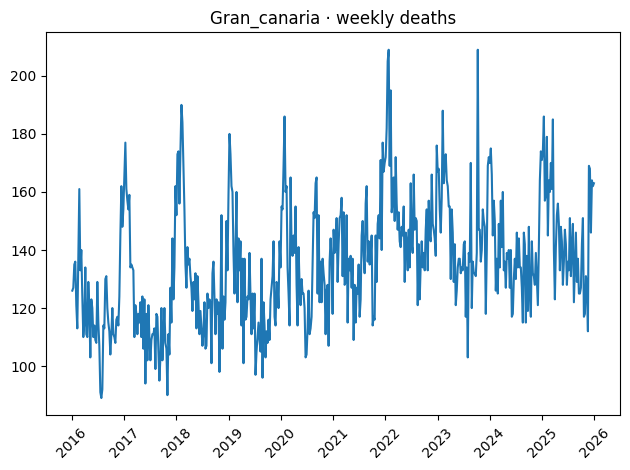

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\gran_canaria\gcan_eda01_weekly_tmax_timeseries.png


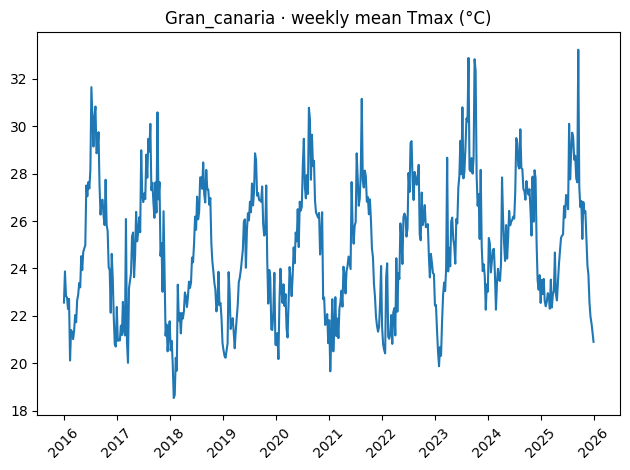

In [29]:
plt.figure()
plt.plot(df["week_start"], df["deaths_week"])
plt.title(f"{ISLAND_NAME.capitalize()} · weekly deaths")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_weekly_deaths_timeseries.png")
plt.show()

if "tmax_c_mean" in df.columns:
    plt.figure()
    plt.plot(df["week_start"], df["tmax_c_mean"])
    plt.title(f"{ISLAND_NAME.capitalize()} · weekly mean Tmax (°C)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_weekly_tmax_timeseries.png")
    plt.show()

## 5. Temperature and mortality
### 5.1 Absolute temperature vs deaths
Absolute temperature can be heavily confounded by seasonality.

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\gran_canaria\gcan_eda01_deaths_vs_absolute_tmax_scatter.png


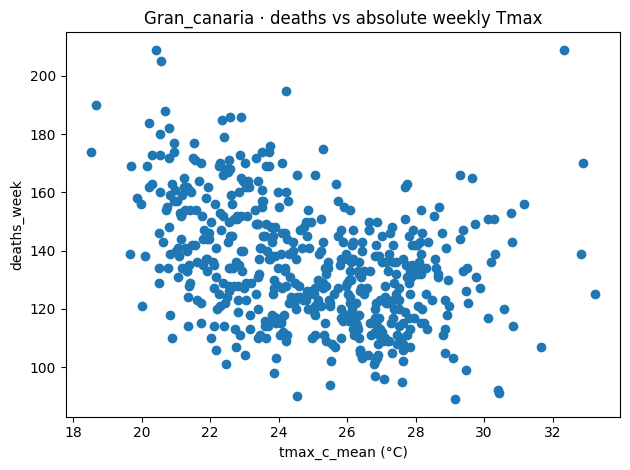

corr(deaths, tmax_c_mean): -0.3727


In [30]:
if {"tmax_c_mean", "deaths_week"}.issubset(df.columns):
    plt.figure()
    plt.scatter(df["tmax_c_mean"], df["deaths_week"])
    plt.xlabel("tmax_c_mean (°C)")
    plt.ylabel("deaths_week")
    plt.title(f"{ISLAND_NAME.capitalize()} · deaths vs absolute weekly Tmax")
    plt.tight_layout()
    autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_deaths_vs_absolute_tmax_scatter.png")
    plt.show()

    corr_abs = df[["deaths_week", "tmax_c_mean"]].corr().iloc[0, 1]
    print("corr(deaths, tmax_c_mean):", round(float(corr_abs), 4))

##### 5.2 Temperature anomaly vs deaths
Use anomalies (relative temperature) to reduce seasonal confounding.

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\gran_canaria\gcan_eda01_deaths_vs_temperature_anomaly_scatter.png


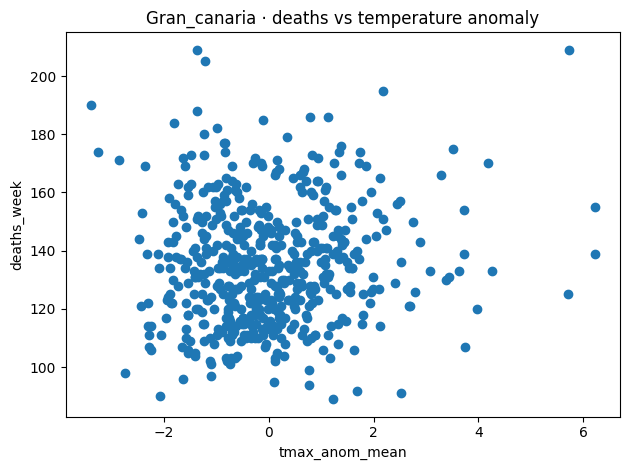

corr(deaths, tmax_anom_mean): 0.0758


In [31]:
anom_col = None
for c in ["tmax_anom_mean_week", "tmax_anom_mean", "tmax_anom_c_mean", "tmax_anom"]:
    if c in df.columns:
        anom_col = c
        break

if anom_col is None:
    print("No anomaly column found in this master. (Skip or create anomalies upstream.)")
else:
    plt.figure()
    plt.scatter(df[anom_col], df["deaths_week"])
    plt.xlabel(anom_col)
    plt.ylabel("deaths_week")
    plt.title(f"{ISLAND_NAME.capitalize()} · deaths vs temperature anomaly")
    plt.tight_layout()
    autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_deaths_vs_temperature_anomaly_scatter.png")
    plt.show()

    corr_anom = df[["deaths_week", anom_col]].corr().iloc[0, 1]
    print(f"corr(deaths, {anom_col}):", round(float(corr_anom), 4))

### 5.3 Extreme heat (p90 / p95)
Compare weeks above an extreme threshold vs the rest.

In [32]:
q90_tmax = df["tmax_c_mean"].quantile(0.90)
q95_tmax = df["tmax_c_mean"].quantile(0.95)

df["heat_p90"] = (df["tmax_c_mean"] >= q90_tmax).astype(int)
df["heat_p95"] = (df["tmax_c_mean"] >= q95_tmax).astype(int)

print(f"Empirical thresholds from weekly tmax_c_mean -> p90={q90_tmax:.2f}, p95={q95_tmax:.2f}")
print(df["heat_p95"].value_counts(dropna=False))

Empirical thresholds from weekly tmax_c_mean -> p90=28.21, p95=29.37
heat_p95
0    495
1     27
Name: count, dtype: int64


In [33]:
tmp = df.copy()
tab_p95 = tmp.groupby("heat_p95")["deaths_week"].agg(["count", "mean", "median"])
display(tab_p95)

if 0 in tab_p95.index and 1 in tab_p95.index:
    delta_p95 = float(tab_p95.loc[1, "mean"] - tab_p95.loc[0, "mean"])
    print("Δ deaths (heat_p95 vs baseline):", round(delta_p95, 2))

,count,mean,median
heat_p95,,,
0,495,135.442424,134.0
1,27,135.037037,134.0


Δ deaths (heat_p95 vs baseline): -0.41


In [34]:
save_table(tab_p95.reset_index(), TAB_DIR, f"heat_p95_deaths_{ISLAND_CODE}.csv", index=False)

Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria\heat_p95_deaths_gcan.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/gran_canaria/heat_p95_deaths_gcan.csv')

## 6. Calima and mortality
Analyze calima intensity proxies vs weekly deaths.

### 6.1 Calima proxy audit
Validate the merged calima proxy coverage and weekly level distribution before using it in downstream comparisons.

,missing,missing_pct
calima_proxy_score,0,0.0
calima_proxy_level,0,0.0


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria\calima_proxy_audit_missing_gcan.csv


,calima_proxy_level,weeks
0,possible,288
1,no_calima,114
2,probable,80
3,intense,40


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria\calima_proxy_level_counts_gcan.csv
Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\gran_canaria\gcan_eda01_calima_proxy_level_distribution.png


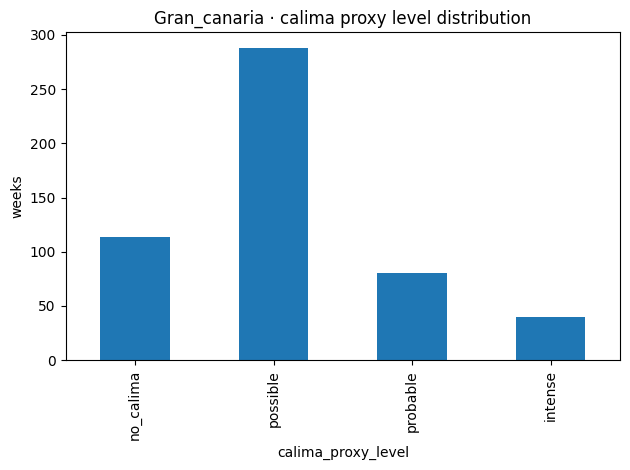

cap_dust_yellow_plus_week,0.0,1.0,NaN
calima_proxy_level,,,
intense,15,16,9
no_calima,95,4,15
possible,201,7,80
probable,52,4,24


In [35]:
proxy_cols = ["calima_proxy_score", "calima_proxy_level"]
have_proxy = all(c in df.columns for c in proxy_cols)

if have_proxy:
    proxy_na = df[proxy_cols].isna().sum().rename("missing").to_frame()
    proxy_na["missing_pct"] = (proxy_na["missing"] / len(df)).round(4)
    display(proxy_na)
    save_table(
        proxy_na.reset_index().rename(columns={"index": "column"}),
        TAB_DIR,
        f"calima_proxy_audit_missing_{ISLAND_CODE}.csv",
        index=False
    )

    proxy_counts = (
        df["calima_proxy_level"]
        .value_counts(dropna=False)
        .rename_axis("calima_proxy_level")
        .reset_index(name="weeks")
    )
    display(proxy_counts)
    save_table(proxy_counts, TAB_DIR, f"calima_proxy_level_counts_{ISLAND_CODE}.csv", index=False)

    plot_counts = df["calima_proxy_level"].dropna().value_counts()
    if not plot_counts.empty:
        desired_order = ["no_calima", "possible", "probable", "intense"]
        plot_counts = plot_counts.reindex([x for x in desired_order if x in plot_counts.index]).dropna()

        plt.figure()
        plot_counts.plot(kind="bar")
        plt.ylabel("weeks")
        plt.title(f"{ISLAND_NAME.capitalize()} · calima proxy level distribution")
        plt.tight_layout()
        autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_calima_proxy_level_distribution.png")
        plt.show()

    if "cap_dust_yellow_plus_week" in df.columns:
        cap_xtab = pd.crosstab(df["calima_proxy_level"], df["cap_dust_yellow_plus_week"], dropna=False)
        display(cap_xtab)

In [36]:
score_dist = (
    df["calima_proxy_score"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("calima_proxy_score")
    .reset_index(name="weeks")
)

score_dist["pct"] = score_dist["weeks"] / len(df) * 100
score_dist["pct"] = score_dist["pct"].round(6)

display(score_dist)

save_table(
    score_dist,
    TAB_DIR,
    f"calima_proxy_score_distribution_{ISLAND_CODE}.csv",
    index=False
)

,calima_proxy_score,weeks,pct
0,0.0,91,17.432950
1,0.5,23,4.406130
2,1.0,227,43.486590
3,1.5,61,11.685824
4,2.0,58,11.111111
5,2.5,22,4.214559
6,3.0,12,2.298851
7,3.5,9,1.724138
8,4.0,4,0.766284
9,4.5,15,2.873563


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria\calima_proxy_score_distribution_gcan.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/gran_canaria/calima_proxy_score_distribution_gcan.csv')

In [37]:
score_level = df.groupby(["calima_proxy_score", "calima_proxy_level"]).size().reset_index(name="weeks")
display(score_level)
save_table(score_level, TAB_DIR, f"calima_proxy_score_to_level_{ISLAND_CODE}.csv", index=False)

,calima_proxy_score,calima_proxy_level,weeks
0,0.0,no_calima,91
1,0.5,no_calima,23
2,1.0,possible,227
3,1.5,possible,61
4,2.0,probable,58
5,2.5,probable,22
6,3.0,intense,12
7,3.5,intense,9
8,4.0,intense,4
9,4.5,intense,15


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria\calima_proxy_score_to_level_gcan.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/gran_canaria/calima_proxy_score_to_level_gcan.csv')

### 6.2 Calima levels and deaths
Compare weekly deaths across calima proxy levels (or DAI fallback if proxy columns are unavailable).

In [38]:
if "calima_proxy_level" in df.columns:
    level_order = ["no_calima", "possible", "probable", "intense"]

    cal = (
        df.groupby("calima_proxy_level")["deaths_week"]
        .agg(["count", "mean", "median", "min", "max", "std"])
        .reindex(level_order)
    )
    display(cal)
    save_table(cal.reset_index(), TAB_DIR, f"calima_proxy_level_v_deaths_{ISLAND_CODE}.csv", index=False)
else:
    print("No calima_proxy_level. Using calima_dai_flag if available...")
    if "calima_dai_flag" in df.columns:
        cal = df.groupby("calima_dai_flag")["deaths_week"].agg(["count", "mean", "median"]).sort_index()
        display(cal)
        save_table(cal.reset_index(), TAB_DIR, f"calima_dai_flag_deaths_{ISLAND_CODE}.csv", index=False)

if "intense" in cal.index and "no_calima" in cal.index:
    mean_intense = cal.loc["intense", "mean"]
    mean_baseline = cal.loc["no_calima", "mean"]
    delta_deaths = mean_intense - mean_baseline

    print(f"Mean deaths | intense   : {mean_intense:.2f}")
    print(f"Mean deaths | no_calima : {mean_baseline:.2f}")
    print(f"Δ deaths (calima intense vs baseline) = {delta_deaths:.2f}")

,count,mean,median,min,max,std
calima_proxy_level,,,,,,
no_calima,114,139.640351,137.5,103.0,179.0,17.576698
possible,288,131.350694,129.5,89.0,190.0,19.632830
probable,80,135.512500,131.5,91.0,209.0,22.045404
intense,40,152.525000,149.0,106.0,209.0,23.357849


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria\calima_proxy_level_v_deaths_gcan.csv
Mean deaths | intense   : 152.53
Mean deaths | no_calima : 139.64
Δ deaths (calima intense vs baseline) = 12.88


In [39]:
tmp = df.copy()
tmp["month"] = pd.to_datetime(tmp["week_start"]).dt.month

month_proxy = (
    tmp.groupby(["month", "calima_proxy_level"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(month_proxy)

save_table(
    month_proxy,
    TAB_DIR,
    f"calima_proxy_level_by_month_{ISLAND_CODE}.csv",
    index=False
)

calima_proxy_level,month,intense,no_calima,possible,probable
0,1,8,11,16,10
1,2,12,6,18,5
2,3,4,9,25,5
3,4,1,12,17,13
4,5,0,11,21,13
5,6,0,6,31,5
6,7,0,5,30,10
7,8,0,9,31,4
8,9,0,10,31,2
9,10,4,13,25,3


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria\calima_proxy_level_by_month_gcan.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/gran_canaria/calima_proxy_level_by_month_gcan.csv')

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\gran_canaria\deaths_by_calima_proxy_level_boxplot_gcan.png


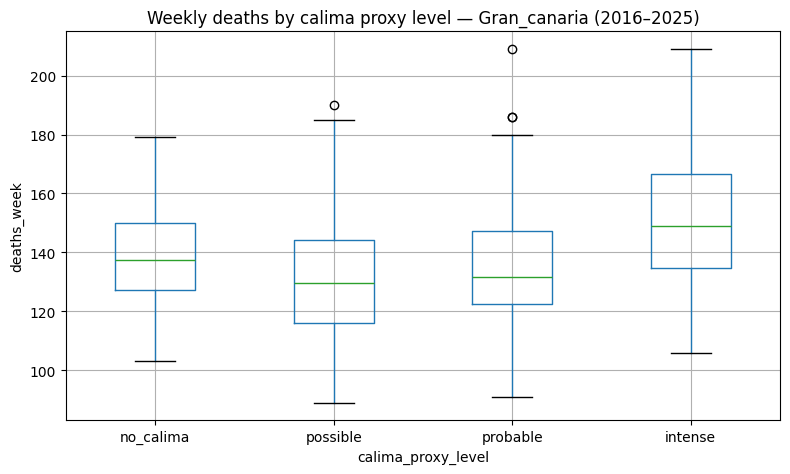

In [40]:
level_order = ["no_calima", "possible", "probable", "intense"]

plot_df = df.dropna(subset=["calima_proxy_level", "deaths_week"]).copy()
plot_df["calima_proxy_level"] = pd.Categorical(
    plot_df["calima_proxy_level"],
    categories=level_order,
    ordered=True
)
plot_df = plot_df.sort_values("calima_proxy_level")

fig, ax = plt.subplots(figsize=(8, 5))
plot_df.boxplot(column="deaths_week", by="calima_proxy_level", ax=ax)

ax.set_title(f"Weekly deaths by calima proxy level — {ISLAND_NAME.capitalize()} (2016–2025)")
ax.set_xlabel("calima_proxy_level")
ax.set_ylabel("deaths_week")
plt.suptitle("")
plt.tight_layout()

autosave_fig(FIG_DIR / f"deaths_by_calima_proxy_level_boxplot_{ISLAND_CODE}.png")
plt.show()

## 7. Interaction: extreme heat × calima
A simple 2×2 cross-tab.

In [41]:
tmp = df.copy()

if "calima_proxy_level" in tmp.columns:
    tmp["calima_intense"] = (tmp["calima_proxy_level"] == "intense").astype(int)
else:
    tmp["calima_intense"] = 0

inter = tmp.groupby(["heat_p95", "calima_intense"])["deaths_week"].agg(["count", "mean", "median"])
display(inter)

save_table(
    inter.reset_index(),
    TAB_DIR,
    f"interaction_heat_p95_x_calima_intense_{ISLAND_CODE}.csv",
    index=False
)

count        mean  median
heat_p95 calima_intense                           
0        0                 457  133.921225   133.0
         1                  38  153.736842   150.0
1        0                  25  135.480000   134.0
         1                   2  129.500000   129.5

Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria\interaction_heat_p95_x_calima_intense_gcan.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/gran_canaria/interaction_heat_p95_x_calima_intense_gcan.csv')

In [42]:
summary = {}

# 1) Δ deaths: heat p95 vs baseline
if "heat_p95" in df.columns and "deaths_week" in df.columns:
    heat_base = df.loc[df["heat_p95"] == 0, "deaths_week"].mean()
    heat_p95 = df.loc[df["heat_p95"] == 1, "deaths_week"].mean()
    summary["deaths_mean_baseline_heat"] = heat_base
    summary["deaths_mean_heat_p95"] = heat_p95
    summary["delta_deaths_heat_p95_vs_baseline"] = heat_p95 - heat_base
else:
    summary["deaths_mean_baseline_heat"] = np.nan
    summary["deaths_mean_heat_p95"] = np.nan
    summary["delta_deaths_heat_p95_vs_baseline"] = np.nan

# 2) Δ deaths: calima intense vs baseline
if "calima_proxy_level" in df.columns and "deaths_week" in df.columns:
    cal_base = df.loc[df["calima_proxy_level"] == "no_calima", "deaths_week"].mean()
    cal_intense = df.loc[df["calima_proxy_level"] == "intense", "deaths_week"].mean()
    summary["deaths_mean_no_calima"] = cal_base
    summary["deaths_mean_intense_calima"] = cal_intense
    summary["delta_deaths_intense_vs_no_calima"] = cal_intense - cal_base
else:
    summary["deaths_mean_no_calima"] = np.nan
    summary["deaths_mean_intense_calima"] = np.nan
    summary["delta_deaths_intense_vs_no_calima"] = np.nan

# 3) Proxy missingness
if "calima_proxy_score" in df.columns:
    summary["proxy_missing_n"] = int(df["calima_proxy_score"].isna().sum())
    summary["proxy_missing_pct"] = df["calima_proxy_score"].isna().mean() * 100
else:
    summary["proxy_missing_n"] = np.nan
    summary["proxy_missing_pct"] = np.nan

# 4) Correlation: deaths vs absolute temperature
temp_col = None
for c in ["tmax_mean", "tmax_c_mean", "tmean_mean", "tmean_c_mean"]:
    if c in df.columns:
        temp_col = c
        break

if temp_col is not None and "deaths_week" in df.columns:
    summary["temp_corr_col_used"] = temp_col
    summary["corr_deaths_vs_temp"] = df["deaths_week"].corr(df[temp_col])
else:
    summary["temp_corr_col_used"] = None
    summary["corr_deaths_vs_temp"] = np.nan

# 5) Correlation: deaths vs temperature anomaly
anom_col = None
for c in ["tmax_anom_mean", "tmean_anom_mean", "temp_anom_mean"]:
    if c in df.columns:
        anom_col = c
        break

if anom_col is not None and "deaths_week" in df.columns:
    summary["anom_corr_col_used"] = anom_col
    summary["corr_deaths_vs_anomaly"] = df["deaths_week"].corr(df[anom_col])
else:
    summary["anom_corr_col_used"] = None
    summary["corr_deaths_vs_anomaly"] = np.nan

# Output table
summary_df = pd.DataFrame(
    {"metric": summary.keys(), "value": summary.values()}
)

display(Markdown(f"""
### Key numbers — {ISLAND_NAME.upper()}
<hr></hr>

**Δ deaths (heat p95 vs baseline):** {summary['delta_deaths_heat_p95_vs_baseline']:.2f}

**Δ deaths (intense calima vs no_calima):** {summary['delta_deaths_intense_vs_no_calima']:.2f} deaths/week

**Proxy missingness:** {summary['proxy_missing_n']} weeks ({summary['proxy_missing_pct']:.2f}%)

**Corr deaths vs temp ({summary['temp_corr_col_used']}):** {summary['corr_deaths_vs_temp']:.3f}

**Corr deaths vs anomaly ({summary['anom_corr_col_used']}):** {summary['corr_deaths_vs_anomaly']:.3f}
<br></br>
"""))
save_table(
    summary_df,
    TAB_DIR,
    f"key_numbers_auto_{ISLAND_CODE}.csv",
    index=False
)


### Key numbers — GRAN_CANARIA
<hr></hr>

**Δ deaths (heat p95 vs baseline):** -0.41

**Δ deaths (intense calima vs no_calima):** 12.88 deaths/week

**Proxy missingness:** 0 weeks (0.00%)

**Corr deaths vs temp (tmax_c_mean):** -0.373

**Corr deaths vs anomaly (tmax_anom_mean):** 0.076
<br></br>


Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\gran_canaria\key_numbers_auto_gcan.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/gran_canaria/key_numbers_auto_gcan.csv')